In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/project_3/uber_cleaned.xlsx')

In [ ]:
df.head()

,Row_ID,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,...,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Datetime,Hour,DayOfWeek
0,0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday
1,1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,...,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday
2,2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,...,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday
3,3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,...,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday
4,4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,...,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday


In [ ]:
df['Month'] = df['Datetime'].dt.month_name()
df['Quarter'] = df['Datetime'].dt.quarter

In [ ]:
df['Is_Weekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday'])

In [ ]:
# Time Slot — demand-window analysis
def time_slot(h):
    if 5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else: return 'Night'
df['Time_Slot'] = df['Hour'].apply(time_slot)
df['Time_Slot'].value_counts()

,count
Time_Slot,
Morning,45458
Evening,44118
Afternoon,37342
Night,23082


**Time Slot:**

Demand is concentrated in Morning (45,458 rides, 30%) and Evening (44,118, 29%), together 59% of total volume, consistent with commute patterns. Night is lowest (23,082, 15%), signaling lower driver supply needs after hours.


In [ ]:
import numpy as np
df['Booking_Success'] = np.where(df['Booking Status'] == 'Completed', 1, 0)
df['Booking_Success'].value_counts()

,count
Booking_Success,
1,93000
0,57000


**Booking Success:** Of 150,000 bookings, only 93,000 (62%) completed successfully a 38% failure rate. This is the single biggest red flag , over a third of demand is never fulfilled.

In [ ]:
#Cancellation Flag.....root cause segmentation
def cancel_flag(row):
    if row['Cancelled Rides by Customer'] == 1: return 'Customer Cancelled'
    elif row['Cancelled Rides by Driver'] == 1: return 'Driver Cancelled'
    elif row['Booking Status'] == 'No Driver Found': return 'No Driver Found'
    elif row['Incomplete Rides'] == 1: return 'Incomplete'
    elif row['Booking Status'] == 'Completed': return 'Completed'
    else: return 'Other'
df['Cancellation_Category'] = df.apply(cancel_flag, axis=1)
df['Cancellation_Category'].value_counts()

,count
Cancellation_Category,
Completed,93000
Driver Cancelled,27000
No Driver Found,10500
Customer Cancelled,10500
Incomplete,9000


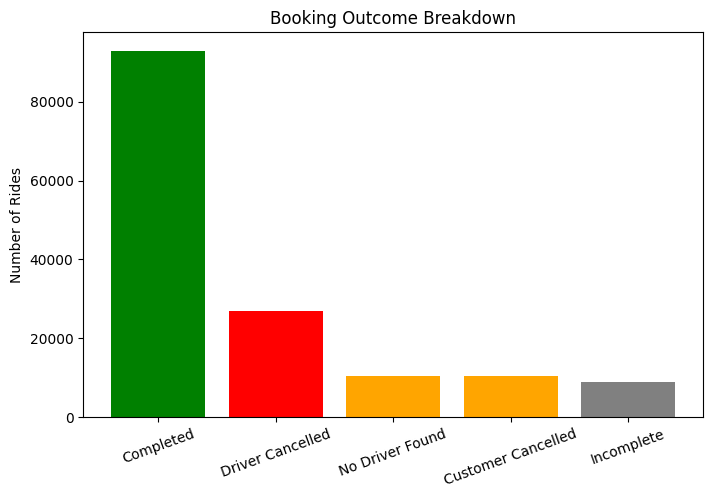

In [ ]:
import matplotlib.pyplot as plt

# 1. Cancellation breakdown — shows driver is dominant failure cause
cancel_counts = df['Cancellation_Category'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(cancel_counts.index, cancel_counts.values, color=['green','red','orange','orange','gray'])
plt.title('Booking Outcome Breakdown')
plt.ylabel('Number of Rides')
plt.xticks(rotation=20)
plt.show()

**Cancellation Category:** Of the 57,000 failed bookings, Driver Cancellations account for 27,000 (47% of all failures, 18% of total bookings), the dominant failure driver, far ahead of "No Driver Found" (10,500) and Customer Cancellations (10,500, tied). Incomplete rides add 9,000 more. This points to a driver-side reliability problem (acceptance behavior or matching issue), not a demand-side or supply-shortage problem.

In [ ]:
# 7. Revenue Category — quantile-based, business-relevant tiers
df['Revenue_Category'] = pd.qcut(
    df['Booking Value'].dropna(),
    q=[0, 0.33, 0.66, 1.0],
    labels=['Low Value', 'Mid Value', 'High Value']
)
df['Revenue_Category'].value_counts()

,count
Revenue_Category,
High Value,34634
Low Value,33732
Mid Value,33634


**Revenue Category:** Revenue tiers are evenly split (~33% each: High 34,634 / Low 33,732 / Mid 33,634), expected since this was built on quantiles , confirms no major revenue skew requiring action.

In [ ]:
df['Driver Cancellation Reason'].value_counts()

,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


**Driver Cancellation Reason:** The four reasons are nearly evenly split (~25% each: 6,837 / 6,751 / 6,726 / 6,686 out of ~27,000), no single dominant cause. "Customer related issue" and "customer coughing/sick" combined account for ~50% of driver cancellations, suggesting customer-side friction (real or used as an excuse) is as big a factor as vehicle/personal issues.

In [ ]:
loc_cancel = df[df['Cancellation_Category']=='Driver Cancelled'].groupby('Pickup Location').size().sort_values(ascending=False).head(10)
print(loc_cancel)

Pickup Location
Nehru Place       190
Shivaji Park      185
GTB Nagar         183
Pragati Maidan    179
Saket             179
AIIMS             176
Vinobapuri        176
Rajouri Garden    176
Punjabi Bagh      176
Nawada            174
dtype: int64


**Pickup Location:** Cancellations are spread thinly across many locations (top location Nehru Place at only 190 out of 27,000 = 0.7%), no geographic hotspot. This rules out location as a root cause; the problem is platform-wide, not zone-specific.

In [ ]:
veh_cancel = pd.crosstab(df['Vehicle Type'], df['Cancellation_Category'], normalize='index') * 100
print(veh_cancel[['Driver Cancelled']].sort_values('Driver Cancelled', ascending=False))

Cancellation_Category  Driver Cancelled
Vehicle Type                           
Go Sedan                      18.536531
Bike                          18.106320
eBike                         18.063844
Premier Sedan                 17.944895
Go Mini                       17.882306
Auto                          17.753013
Uber XL                       17.127444


**Vehicle Type:** Cancellation rate is nearly identical across all vehicle types (17.1%–18.5%, a <1.5 point spread), Go Sedan highest at 18.5%, Uber XL lowest at 17.1%. No vehicle category is significantly worse, ruling out vehicle type as a driver.

---


##Overall Insight:

The driver-cancellation problem (18% of all bookings) is uniform , not concentrated by time, location, or vehicle type — meaning it's a systemic behavioral/process issue rather than a localized operational gap